[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mihdicaballero/mento/blob/main/docs/source/examples/viga_rectangular_verificacion_CIRSOC_201-25.ipynb)

In [1]:
# Google Colab no trae mento instalado, así que lo instalamos sólo cuando el
# notebook corre allí. La guarda evita que la documentación llame a pip.
import sys

if "google.colab" in sys.modules:
    %pip install mento

# Verificación de viga rectangular — CIRSOC 201-25

Acá la armadura ya está definida — porque viene de un plano, de un cálculo anterior o de una
estructura existente — y lo que queremos saber es si verifica según el **CIRSOC 201-2025**.

Es el camino inverso al del ejemplo de
[diseño](viga_rectangular_diseno_CIRSOC_201-25.ipynb): en lugar de pedirle a mento que elija
las barras, se las imponemos y le pedimos la relación demanda-capacidad.


**Materiales y geometría de la sección**

In [2]:
from mento import Concrete_CIRSOC_201_25, SteelBar, RectangularBeam, cm, mm, kN, MPa, kNm
from mento import Forces, Node

hormigon = Concrete_CIRSOC_201_25(name="H-25", f_c=25 * MPa)
acero = SteelBar(name="ADN 420", f_y=420 * MPa)

viga = RectangularBeam(
    label="V201",
    concrete=hormigon,
    steel_bar=acero,
    width=20 * cm,
    height=50 * cm,
    c_c=2.5 * cm,
)
viga.data

Beam V201, $b$=20.00 cm, $h$=50.00 cm, $c_{c}$=2.50 cm,                             Concrete H-25, Rebar ADN 420.

**Armadura existente**

La armadura longitudinal se carga por cara y por capa; los estribos, con la cantidad de
estribos, el diámetro y la separación longitudinal.

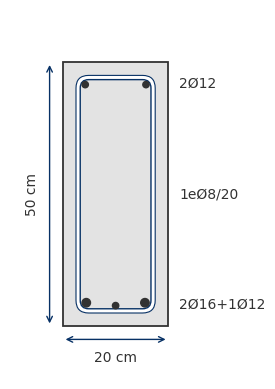

In [3]:
# Armadura longitudinal inferior: 2Ø16 en la primera capa y 1Ø12 en la segunda
viga.set_longitudinal_rebar_bot(n1=2, d_b1=16 * mm, n2=1, d_b2=12 * mm)

# Armadura longitudinal superior: 2Ø12
viga.set_longitudinal_rebar_top(n1=2, d_b1=12 * mm)

# Estribos: 1 estribo (2 ramas) Ø8 cada 20 cm
viga.set_transverse_rebar(n_stirrups=1, d_b=8 * mm, s_l=20 * cm)

viga.plot()

**Estados de carga y nodo**

In [4]:
f1 = Forces(label="1.2D+1.6L", M_y=80 * kNm, V_z=50 * kN)
f2 = Forces(label="1.2D+1.6L+W", M_y=-30 * kNm, V_z=55 * kN)

nodo = Node(section=viga, forces=[f1, f2])
nodo

Node ID: 1 - Section label: V201
Forces Applied:
  - Force ID: 1, Label: 1.2D+1.6L, N_x: 0.00 kN, V_z: 50.00 kN, M_y: 80.00 kN·m
  - Force ID: 2, Label: 1.2D+1.6L+W, N_x: 0.00 kN, V_z: 55.00 kN, M_y: -30.00 kN·m

**Verificación**

`check()` corre flexión y corte para todas las combinaciones. La columna DCR es la relación
demanda-capacidad: verifica mientras sea menor o igual a 1.

In [5]:
nodo.check()
nodo.results

Beam V201, $b$=20.00 cm, $h$=50.00 cm, $c_{c}$=2.50 cm,                             Concrete H-25, Rebar ADN 420.

Top longitudinal rebar: 2Ø12, $A_{s,top}$ = 2.26 cm², $M_u$ = -30 kNm, $\phi M_n$ = 38.46 kNm → $\color{#439b00}{\text{DCR}=0.78}$ 

Bottom longitudinal rebar: 2Ø16+1Ø12, $A_{s,bot}$ = 5.15 cm², $M_u$ = 80 kNm, $\phi M_n$ = 84.52 kNm → $\color{#efc200}{\text{DCR}=0.95}$ 

Shear reinforcing 1eØ8/20 cm, $A_v$=5.03 cm²/m, $V_u$=55 kN, $\phi V_n$=131.32 kN → $\color{#439b00}{\text{DCR}=0.42}$ 

In [6]:
nodo.check_flexure()

,Label,Comb.,Position,"As,min","As,req top","As,req bot",As,Mu,ØMn,Mu≤ØMn,DCR
0,,,,cm²,cm²,cm²,cm²,kNm,kNm,,
1,V201,1.2D+1.6L,Bottom,3.06,0.0,4.86,5.15,80,84.52,True,0.947
2,V201,1.2D+1.6L+W,Top,3.07,2.34,0.0,2.26,-30,38.46,True,0.78


In [7]:
nodo.check_shear()

,Label,Comb.,"Av,min","Av,req",Av,Vu,Nu,ØVc,ØVs,ØVn,ØVmax,Vu≤ØVmax,Vu≤ØVn,DCR
0,,,cm²/m,cm²/m,cm²/m,kN,kN,kN,kN,kN,kN,,,
1,V201,1.2D+1.6L,1.67,1.67,5.03,50,0,58.58,72.75,131.32,286.0,True,True,0.381
2,V201,1.2D+1.6L+W,1.67,1.67,5.03,55,0,58.58,72.75,131.32,286.0,True,True,0.419


**Lectura de la verificación desde el código**

Después de un `check()`, `flexure_design` y `shear_design` describen la armadura verificada y
su DCR, sin tener que leer la tabla. Los DCR son la envolvente de todos los estados de carga,
es decir, el de la combinación que gobierna cada cara.

In [8]:
flexion = viga.flexure_design
corte = viga.shear_design

print("Armadura inferior:", flexion.bottom, f"→ As = {flexion.bottom.A_s.to('cm**2'):.2f~P}")
print("Armadura superior:", flexion.top, f"→ As = {flexion.top.A_s.to('cm**2'):.2f~P}")
print("Estribos:", corte)
print(f"DCR flexión = {flexion.DCR:.2f} | DCR corte = {corte.DCR:.2f}")
print("Verifica" if max(flexion.DCR, corte.DCR) <= 1 else "No verifica")

Armadura inferior: 2Ø16 mm + 1Ø12 mm → As = 5.15 cm²
Armadura superior: 2Ø12 mm → As = 2.26 cm²
Estribos: 1eØ8 mm/20 cm
DCR flexión = 0.78 | DCR corte = 0.42
Verifica


**Memoria de cálculo detallada**

Para la combinación que gobierna, con cada verificación del reglamento paso a paso.

In [9]:
nodo.flexure_results_detailed()

===== BEAM FLEXURE DETAILED RESULTS =====
Materials                            Variable     Value  Unit
----------------------------------  ----------  -------  ------
Section Label                                      V201
Concrete strength                       fc           25  MPa
Steel reinforcement yield strength      fy          420  MPa 

Geometry                  Variable     Value  Unit
-----------------------  ----------  -------  ------
Section height               h            50  cm
Section width                b            20  cm
Clear cover                  cc          2.5  cm
Mechanical top cover       cm,top        3.9  cm
Mechanical bottom cover    cm,bot       4.06  cm 

Design forces       Variable     Value  Unit
-----------------  ----------  -------  ------
Top max moment       Mu,top        -30  kNm
Bottom max moment    Mu,bot         80  kNm 

Check                     Unit     Value  Min.      Max.  Ok?
-----------------------  ------  -------  ------  ------ 

In [10]:
nodo.shear_results_detailed()

===== BEAM SHEAR DETAILED RESULTS =====
Materials                            Variable     Value  Unit
----------------------------------  ----------  -------  ------
Section Label                                      V201
Concrete strength                       fc           25  MPa
Steel reinforcement yield strength      fy          420  MPa
Concrete density                        wc       2500.0  kg/m³
Normalweight concrete                   λ             1
Safety factor for shear                 Øv         0.75 

Geometry                     Variable     Value  Unit
--------------------------  ----------  -------  ------
Section height                  h            50  cm
Section width                   b            20  cm
Clear cover                     cc          2.5  cm
Longitudinal tension rebar      As         2.26  cm² 

Design forces                     Variable     Value  Unit
-------------------------------  ----------  -------  ------
Axial, positive for compression      N